# Теория и практика нейронных сетей
## Реализация архитектур RNN, GRU, LSTM
### Датасет: Bike Sharing Dataset (day.csv)

**Задача**: предсказание суммарного количества аренд велосипедов (`cnt`) на основе исторических данных и признаков.

---

## 0. Установка зависимостей

In [152]:
#!pip install torch torchvision torchaudio --quiet
#!pip install pandas numpy matplotlib scikit-learn --quiet

## 1. Импорт библиотек

In [153]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

# Воспроизводимость
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Устройство
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Используемое устройство: {device}')
print(f'PyTorch версия: {torch.__version__}')

Используемое устройство: cpu
PyTorch версия: 2.10.0+cpu


## 2. Загрузка и подготовка датасета

In [154]:
# Загрузка данных
# Если запускаете в Google Colab — загрузите файл day.csv вручную или через:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('dataset.csv')
print('Форма датасета:', df.shape)
print('\nПервые 5 строк:')
df.head()

Saving dataset.csv to dataset (5).csv
Форма датасета: (731, 16)

Первые 5 строк:


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [155]:
print('Информация о датасете:')
df.info()
print('\nСтатистика:')
df.describe()

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB

Статистика:


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [156]:
# Проверка пропущенных значений
print('Пропущенные значения:')
print(df.isnull().sum())

Пропущенные значения:
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


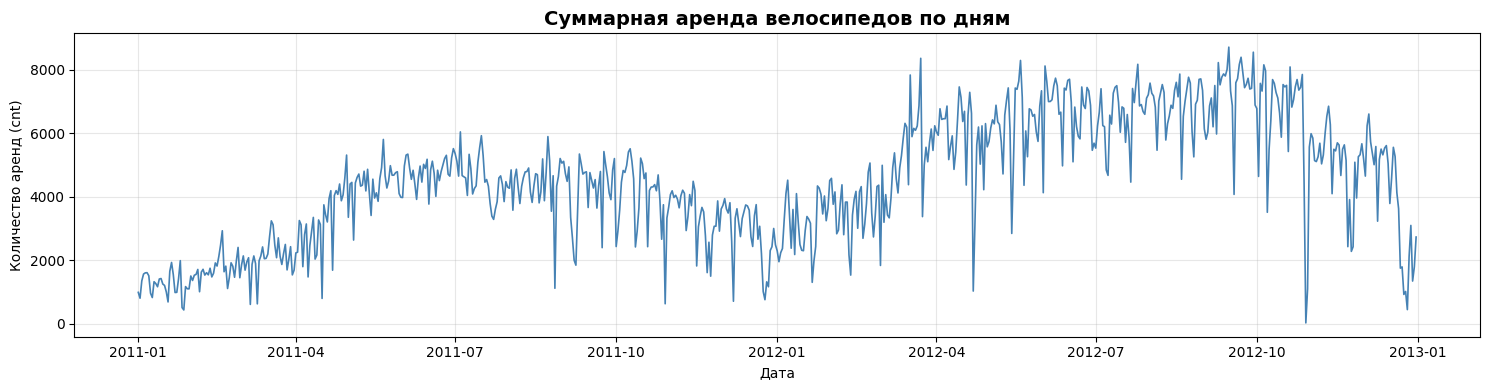


Всего записей: 731
Период: 2011-01-01 00:00:00 — 2012-12-31 00:00:00


In [157]:
# Выбор признаков
# Univariate подход — только целевой ряд (как в lab3)
target_col = 'cnt'

# Сортировка по дате
df['dteday'] = pd.to_datetime(df['dteday'])
df = df.sort_values('dteday').reset_index(drop=True)

# Визуализация целевой переменной
plt.figure(figsize=(15, 4))
plt.plot(df['dteday'], df['cnt'], color='steelblue', linewidth=1.2)
plt.title('Суммарная аренда велосипедов по дням', fontsize=14, fontweight='bold')
plt.xlabel('Дата')
plt.ylabel('Количество аренд (cnt)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\nВсего записей: {len(df)}')
print(f'Период: {df["dteday"].min()} — {df["dteday"].max()}')


In [158]:
# ============================================================
# Подготовка данных (univariate, как в lab3)
# ============================================================

# Нормализация только по целевому ряду
scaler_y = MinMaxScaler()

y_raw = df[target_col].values.astype(np.float32).reshape(-1, 1)

# Нормализуем по всему ряду (MinMax fit по train — чуть ниже)
n_total = len(y_raw)
n_train_raw = int(n_total * 0.8)
scaler_y.fit(y_raw[:n_train_raw])           # fit только на трейне
y_scaled = scaler_y.transform(y_raw)        # трансформируем весь ряд

# Используем нормализованный ряд как единственный признак
X_scaled = y_scaled.copy()                  # shape: (N, 1) — один признак

# Параметры скользящего окна
SEQ_LEN   = 14       # длина входной последовательности (2 недели, как в lab3)
PRED_STEP = 1        # шаг предсказания

def create_sequences(X, y, seq_len):
    """Создаёт скользящие окна из временного ряда."""
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, SEQ_LEN)
print(f'Форма X_seq: {X_seq.shape}  (samples, seq_len, features)')
print(f'Форма y_seq: {y_seq.shape}')


Форма X_seq: (717, 14, 1)  (samples, seq_len, features)
Форма y_seq: (717, 1)


In [159]:
# Train/Test split 80% / 20% (без отдельного val, как в lab3)
n = len(X_seq)
n_train = int(n * 0.80)

X_train, y_train = X_seq[:n_train],  y_seq[:n_train]
X_test,  y_test  = X_seq[n_train:],  y_seq[n_train:]

# Для мониторинга early stopping используем тест (как в lab3)
X_val, y_val = X_test, y_test

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

# Конвертация в тензоры PyTorch
def to_tensor(arr):
    return torch.tensor(arr, dtype=torch.float32).to(device)

X_train_t = to_tensor(X_train)
y_train_t = to_tensor(y_train)
X_val_t   = to_tensor(X_val)
y_val_t   = to_tensor(y_val)
X_test_t  = to_tensor(X_test)
y_test_t  = to_tensor(y_test)

BATCH_SIZE = 32
train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=BATCH_SIZE, shuffle=True
)


Train: 573 | Test: 144


## 3. Вспомогательные функции

In [160]:
# ============================================================
# Ручные вспомогательные примитивы (без autograd и sklearn)
# ============================================================

def _sigmoid(x):
    """Сигмоида (стабилизированная)."""
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def _manual_dropout(x, rate=0.2, training=True):
    """Ручной Dropout: бернуллиевская маска с масштабированием 1/(1-rate)."""
    if not training or rate == 0.0:
        return x, None
    mask = (np.random.binomial(1, 1.0 - rate, x.shape) / (1.0 - rate)).astype(x.dtype)
    return x * mask, mask

def _manual_inverse(x_scaled, x_min, x_max):
    """Ручная обратная MinMax-нормировка."""
    return x_scaled * (x_max - x_min) + x_min

# --- Ручные метрики ---
def manual_mae(y_true, y_pred):
    """Mean Absolute Error."""
    return float(np.mean(np.abs(y_true - y_pred)))

def manual_rmse(y_true, y_pred):
    """Root Mean Squared Error."""
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def manual_r2(y_true, y_pred):
    """Коэффициент детерминации R²."""
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return float(1.0 - ss_res / (ss_tot + 1e-10))

# --- Ручной оптимизатор Adam ---
class _ManualAdam:
    """
    Adam (Kingma & Ba, 2015), реализованный вручную через numpy.
    Без torch.optim, без autograd.
    """
    def __init__(self, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8, weight_decay=1e-5):
        self.lr = lr; self.beta1 = beta1; self.beta2 = beta2
        self.eps = eps; self.wd = weight_decay
        self.t = 0; self.m = {}; self.v = {}

    def step(self, params: dict, grads: dict):
        self.t += 1
        b1t = 1.0 - self.beta1 ** self.t
        b2t = 1.0 - self.beta2 ** self.t
        for name, p in params.items():
            g = grads[name] + self.wd * p
            if name not in self.m:
                self.m[name] = np.zeros_like(p)
                self.v[name] = np.zeros_like(p)
            self.m[name] = self.beta1 * self.m[name] + (1.0 - self.beta1) * g
            self.v[name] = self.beta2 * self.v[name] + (1.0 - self.beta2) * g ** 2
            m_hat = self.m[name] / b1t
            v_hat = self.v[name] / b2t
            params[name] -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)


# ============================================================
# Вспомогательные функции для БИБЛИОТЕЧНЫХ моделей
# ============================================================

def train_model(model, train_loader, X_val, y_val, epochs=200, lr=1e-3, patience=30):
    """Обучение модели с ранней остановкой."""
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=10, factor=0.5
    )
    criterion = nn.MSELoss()

    best_val_loss = float('inf')
    best_state = None
    no_improve = 0
    train_losses, val_losses = [], []

    for epoch in range(1, epochs + 1):
        model.train()
        batch_losses = []
        for Xb, yb in train_loader:
            optimizer.zero_grad()
            pred = model(Xb)
            loss = criterion(pred, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            batch_losses.append(loss.item())

        train_loss = np.mean(batch_losses)

        model.eval()
        with torch.no_grad():
            val_pred = model(X_val)
            val_loss = criterion(val_pred, y_val).item()

        scheduler.step(val_loss)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= patience:
            print(f'  Ранняя остановка на эпохе {epoch}')
            break

        if epoch % 50 == 0:
            print(f'  Эпоха {epoch:4d} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}')

    model.load_state_dict(best_state)
    return train_losses, val_losses


def evaluate_model(model, X_test, y_test, scaler_y, name='Model'):
    """Оценка библиотечной модели на тестовых данных."""
    model.eval()
    with torch.no_grad():
        y_pred_scaled = model(X_test).cpu().numpy()
    y_test_np = y_test.cpu().numpy()

    y_pred = scaler_y.inverse_transform(y_pred_scaled)
    y_true = scaler_y.inverse_transform(y_test_np)

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)

    print(f'  [{name}] MAE={mae:.1f} | RMSE={rmse:.1f} | R²={r2:.4f}')
    return y_true.flatten(), y_pred.flatten(), {'MAE': mae, 'RMSE': rmse, 'R2': r2}


def plot_loss(train_losses, val_losses, title):
    """График потерь при обучении."""
    plt.figure(figsize=(9, 3))
    plt.plot(train_losses, label='Train Loss', color='royalblue')
    plt.plot(val_losses,   label='Val Loss',   color='tomato')
    plt.title(f'Кривые потерь: {title}', fontsize=12, fontweight='bold')
    plt.xlabel('Эпоха')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_predictions(y_true, y_pred, title, color='darkorange'):
    """График фактических и предсказанных значений."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    ax = axes[0]
    ax.plot(y_true,  label='Фактические',   color='steelblue', linewidth=1.5)
    ax.plot(y_pred,  label='Предсказанные',  color=color,        linewidth=1.5, linestyle='--')
    ax.fill_between(range(len(y_true)), y_true, y_pred, alpha=0.15, color='gray')
    ax.set_title(f'{title}: Фактические vs Предсказанные', fontweight='bold')
    ax.set_xlabel('День (тестовая выборка)')
    ax.set_ylabel('Количество аренд')
    ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[1]
    mn, mx = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    ax.scatter(y_true, y_pred, alpha=0.6, color=color, s=20)
    ax.plot([mn, mx], [mn, mx], 'k--', linewidth=1.2, label='Идеал')
    # Ручной расчёт R² для заголовка графика
    r2 = manual_r2(y_true, y_pred)
    ax.set_title(f'Scatter: Факт vs Предсказание (R²={r2:.4f})', fontweight='bold')
    ax.set_xlabel('Фактические'); ax.set_ylabel('Предсказанные')
    ax.legend(); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# ============================================================
# Обучение и оценка РУЧНЫХ моделей (numpy, без autograd)
# ============================================================

# Параметры нормировки — читаем из подогнанного sklearn-скейлера (числа),
# но обратную трансформацию делаем вручную
_y_mn = float(scaler_y.data_min_[0])
_y_mx = float(scaler_y.data_max_[0])

# numpy-версии данных для ручных моделей
X_train_np    = X_train.astype(np.float64)
y_train_np    = y_train.astype(np.float64)
X_val_np      = X_val.astype(np.float64)
y_val_np      = y_val.astype(np.float64)
X_test_np     = X_test.astype(np.float64)
y_test_np_arr = y_test.astype(np.float64)


def train_manual_model(model, X_tr, y_tr, X_v, y_v,
                        epochs=200, batch_size=32, patience=30):
    """
    Обучение ручной numpy-модели: BPTT + ручной Adam.
    Никакого autograd — градиенты считаются явно в методе model.backward().
    """
    n = X_tr.shape[0]
    best_val_loss = float('inf')
    best_params   = None
    no_improve    = 0
    train_losses, val_losses = [], []

    for epoch in range(1, epochs + 1):
        model.training = True
        idx  = np.random.permutation(n)
        X_sh = X_tr[idx]; y_sh = y_tr[idx]

        batch_losses = []
        for start in range(0, n, batch_size):
            Xb = X_sh[start:start + batch_size]
            yb = y_sh[start:start + batch_size]
            loss = model.step(Xb, yb)          # forward + backward + update
            batch_losses.append(loss)
        train_loss = float(np.mean(batch_losses))

        model.training = False
        y_v_pred = model.forward(X_v)
        val_loss = float(np.mean((y_v_pred - y_v) ** 2))

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_params   = {k: v.copy() for k, v in model.params.items()}
            no_improve    = 0
        else:
            no_improve += 1

        if no_improve >= patience:
            print(f'  Ранняя остановка на эпохе {epoch}')
            break

        if epoch % 50 == 0:
            print(f'  Эпоха {epoch:4d} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}')

    model.params    = best_params
    model.training  = False
    return train_losses, val_losses


def evaluate_manual_model(model, X_tst, y_tst, y_min, y_max, name='Model'):
    """
    Оценка ручной модели: ручная обратная нормировка + ручные метрики.
    Без sklearn, без autograd.
    """
    model.training = False
    y_pred_sc = model.forward(X_tst).flatten()
    y_tst_fl  = y_tst.flatten()

    y_pred = _manual_inverse(y_pred_sc, y_min, y_max)
    y_true = _manual_inverse(y_tst_fl,  y_min, y_max)

    mae  = manual_mae(y_true,  y_pred)
    rmse = manual_rmse(y_true, y_pred)
    r2   = manual_r2(y_true,   y_pred)

    print(f'  [{name}] MAE={mae:.1f} | RMSE={rmse:.1f} | R²={r2:.4f}')
    return y_true, y_pred, {'MAE': mae, 'RMSE': rmse, 'R2': r2}


print('Вспомогательные функции определены.')


Вспомогательные функции определены.


---
## 4. RNN

### 4.1. Ручная реализация RNN

Формула:
$$h_t = \tanh(W_{xh} x_t + W_{hh} h_{t-1} + b_h)$$
$$\hat{y} = W_{hy} h_T + b_y$$

In [161]:
class ManualRNN:
    """
    Ручная реализация RNN на чистом numpy.
    Прямой проход, BPTT и обновление весов — без autograd PyTorch.

    h_t = tanh(x_t @ W_xh^T + h_{t-1} @ W_hh^T + b_h)
    y   = h_T_drop @ W_hy^T + b_y
    """
    def __init__(self, input_size, hidden_size, output_size=1, dropout_rate=0.2):
        self.hidden_size   = hidden_size
        self.dropout_rate  = dropout_rate
        self.training      = True
        k = 0.1

        self.params = {
            'W_xh': np.random.randn(hidden_size, input_size)  * k,
            'W_hh': np.random.randn(hidden_size, hidden_size) * k,
            'b_h':  np.zeros(hidden_size),
            'W_hy': np.random.randn(output_size, hidden_size) * k,
            'b_y':  np.zeros(output_size),
        }
        self.opt = _ManualAdam()

    # ------------------------------------------------------------------
    def forward(self, x):
        """x: (batch, seq_len, input_size) -> y: (batch, output_size)"""
        bs, seq_len, _ = x.shape
        p  = self.params
        h  = np.zeros((bs, self.hidden_size), dtype=x.dtype)
        hs = [h]                                      # hs[0] = h_0

        for t in range(seq_len):
            x_t = x[:, t, :]
            h   = np.tanh(x_t @ p['W_xh'].T + h @ p['W_hh'].T + p['b_h'])
            hs.append(h)

        h_drop, self._drop_mask = _manual_dropout(h, self.dropout_rate, self.training)
        y = h_drop @ p['W_hy'].T + p['b_y']

        self._cache = {'x': x, 'hs': hs, 'h_drop': h_drop, 'seq_len': seq_len}
        return y

    # ------------------------------------------------------------------
    def backward(self, dy):
        """
        BPTT: аналитические градиенты по всем параметрам.
        dy: (batch, output_size) — градиент функции потерь по выходу.
        """
        p     = self.params
        cache = self._cache
        x, hs, h_drop, seq_len = cache['x'], cache['hs'], cache['h_drop'], cache['seq_len']
        bs    = x.shape[0]

        grads = {k: np.zeros_like(v) for k, v in p.items()}

        # Выходной слой
        grads['W_hy'] = dy.T @ h_drop
        grads['b_y']  = dy.sum(axis=0)

        # Gradient до dropout: dy уже /bs из step() — здесь не делим повторно
        if self._drop_mask is not None:
            dh = (dy @ p['W_hy']) * self._drop_mask
        else:
            dh = dy @ p['W_hy']                       # (batch, hidden)

        for t in reversed(range(seq_len)):
            h_t    = hs[t + 1]                        # (batch, hidden)
            h_prev = hs[t]
            x_t    = x[:, t, :]

            d_tanh  = 1.0 - h_t ** 2                 # производная tanh
            dh_raw  = dh * d_tanh                    # (batch, hidden)

            grads['W_xh'] += dh_raw.T @ x_t
            grads['W_hh'] += dh_raw.T @ h_prev
            grads['b_h']  += dh_raw.sum(axis=0)

            dh = dh_raw @ p['W_hh']               # передаём назад по времени

        # Обрезка градиентов (clip norm=1)
        total_norm = np.sqrt(sum(np.sum(g**2) for g in grads.values()))
        if total_norm > 1.0:
            for k in grads:
                grads[k] = grads[k] / total_norm

        return grads

    # ------------------------------------------------------------------
    def step(self, x, y_true):
        """Один шаг: forward → loss → backward → Adam update → loss."""
        y_pred = self.forward(x)
        loss   = float(np.mean((y_pred - y_true) ** 2))
        dy     = 2.0 * (y_pred - y_true) / x.shape[0]
        grads  = self.backward(dy)
        self.opt.step(self.params, grads)
        return loss


INPUT_SIZE  = X_train.shape[2]
HIDDEN_SIZE = 16
EPOCHS      = 200

print(f'Число входных признаков: {INPUT_SIZE}')
print('=== Ручная RNN (numpy + BPTT) ===')
manual_rnn = ManualRNN(INPUT_SIZE, HIDDEN_SIZE)
total = sum(v.size for v in manual_rnn.params.values())
print(f'Параметров: {total:,}')


Число входных признаков: 1
=== Ручная RNN (numpy + BPTT) ===
Параметров: 305


Обучение ManualRNN...
  Эпоха   50 | Train Loss: 0.016136 | Val Loss: 0.025591
  Эпоха  100 | Train Loss: 0.013356 | Val Loss: 0.023739
  Эпоха  150 | Train Loss: 0.012907 | Val Loss: 0.023673
  Эпоха  200 | Train Loss: 0.012063 | Val Loss: 0.023574


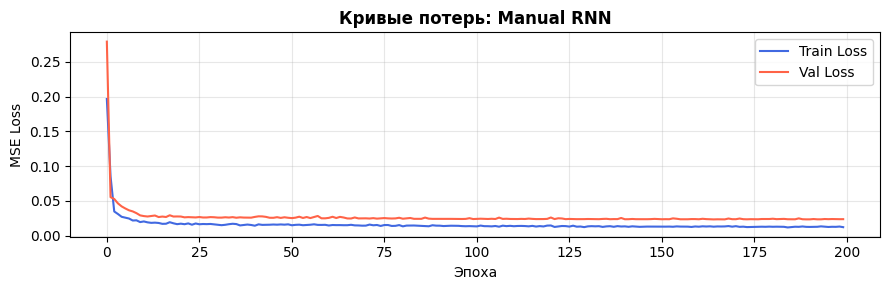

Оценка ManualRNN на тесте:
  [Manual RNN] MAE=863.6 | RMSE=1209.2 | R²=0.5871


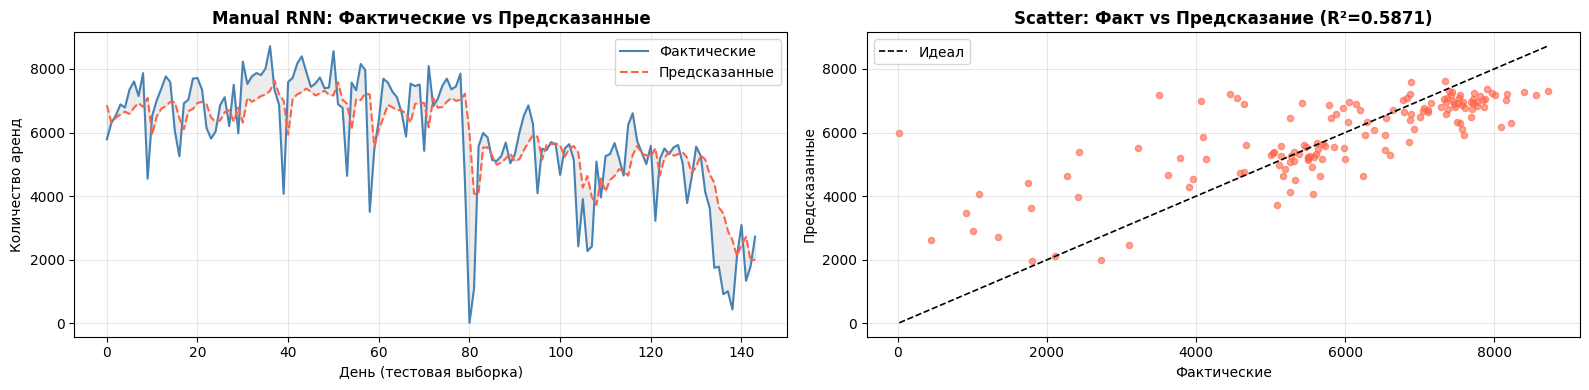

In [162]:
print('Обучение ManualRNN...')
rnn_manual_train_losses, rnn_manual_val_losses = train_manual_model(
    manual_rnn, X_train_np, y_train_np, X_val_np, y_val_np,
    epochs=EPOCHS, batch_size=32, patience=40
)
plot_loss(rnn_manual_train_losses, rnn_manual_val_losses, 'Manual RNN')

print('Оценка ManualRNN на тесте:')
y_true_rnn_m, y_pred_rnn_m, metrics_rnn_m = evaluate_manual_model(
    manual_rnn, X_test_np, y_test_np_arr, _y_mn, _y_mx, 'Manual RNN'
)
plot_predictions(y_true_rnn_m, y_pred_rnn_m, 'Manual RNN', color='tomato')


### 4.2. Библиотечная реализация RNN (torch.nn.RNN)

=== Библиотечная RNN ===
Параметров: 865
Обучение LibRNN...
  Эпоха   50 | Train Loss: 0.017563 | Val Loss: 0.025997
  Эпоха  100 | Train Loss: 0.014558 | Val Loss: 0.025071
  Эпоха  150 | Train Loss: 0.013747 | Val Loss: 0.024312
  Ранняя остановка на эпохе 163


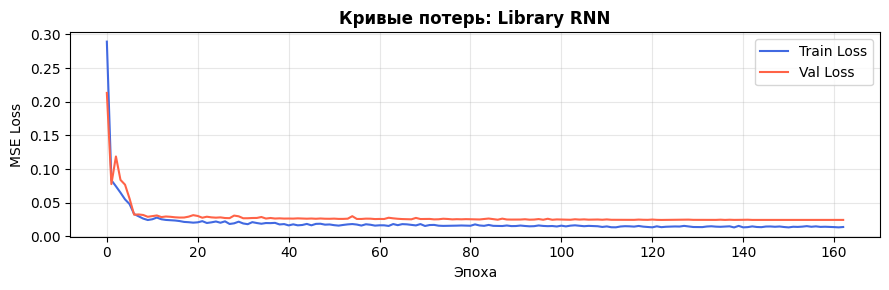

Оценка LibRNN на тесте:
  [Library RNN] MAE=882.8 | RMSE=1235.9 | R²=0.5687


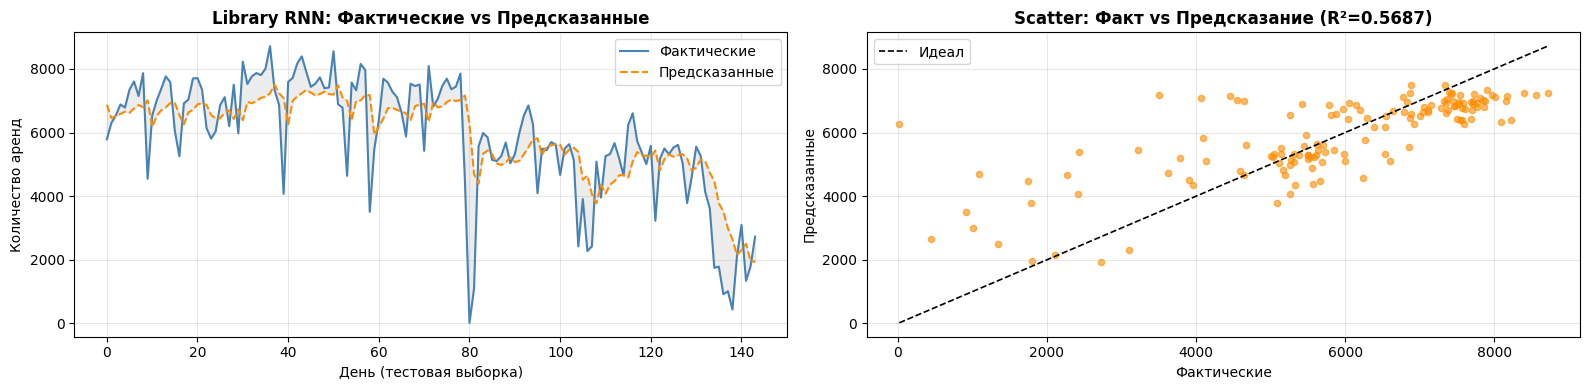

In [163]:
class LibRNN(nn.Module):
    """Библиотечная реализация RNN через torch.nn.RNN."""
    def __init__(self, input_size, hidden_size, num_layers=2, output_size=1, dropout=0.2):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            nonlinearity='tanh'
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # out: (batch, seq_len, hidden_size)
        out, _ = self.rnn(x)
        # Берём вывод последнего шага
        out = self.dropout(out[:, -1, :])
        return self.fc(out)


print('=== Библиотечная RNN ===')
lib_rnn = LibRNN(INPUT_SIZE, HIDDEN_SIZE, num_layers=2).to(device)
print(f'Параметров: {sum(p.numel() for p in lib_rnn.parameters()):,}')

print('Обучение LibRNN...')
rnn_lib_train_losses, rnn_lib_val_losses = train_model(
    lib_rnn, train_loader, X_val_t, y_val_t,
    epochs=EPOCHS, lr=1e-3, patience=40
)
plot_loss(rnn_lib_train_losses, rnn_lib_val_losses, 'Library RNN')

print('Оценка LibRNN на тесте:')
y_true_rnn_l, y_pred_rnn_l, metrics_rnn_l = evaluate_model(
    lib_rnn, X_test_t, y_test_t, scaler_y, 'Library RNN'
)
plot_predictions(y_true_rnn_l, y_pred_rnn_l, 'Library RNN', color='darkorange')

---
## 5. GRU (Gated Recurrent Unit)

### 5.1. Ручная реализация GRU

Формулы:
$$r_t = \sigma(W_r x_t + U_r h_{t-1} + b_r)$$
$$z_t = \sigma(W_z x_t + U_z h_{t-1} + b_z)$$
$$\tilde{h}_t = \tanh(W_h x_t + U_h (r_t \odot h_{t-1}) + b_h)$$
$$h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t$$

=== Ручная GRU (numpy + BPTT) ===
Параметров: 881
Обучение ManualGRU...
  Эпоха   50 | Train Loss: 0.014694 | Val Loss: 0.025720
  Ранняя остановка на эпохе 97


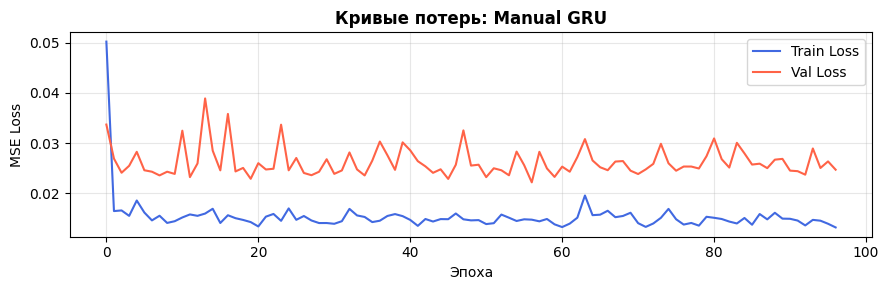

Оценка ManualGRU на тесте:
  [Manual GRU] MAE=870.9 | RMSE=1181.9 | R²=0.6055


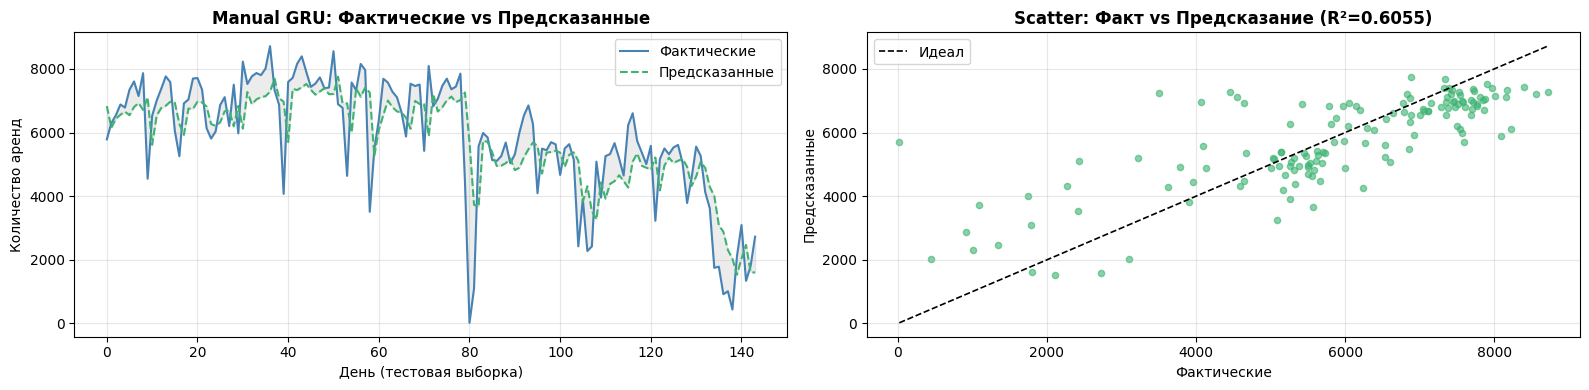

In [164]:
class ManualGRU:
    """
    Ручная реализация GRU на чистом numpy.
    Прямой проход, BPTT по всем вентилям — без autograd PyTorch.

    r_t     = σ(W_r x_t + U_r h_{t-1} + b_r)
    z_t     = σ(W_z x_t + U_z h_{t-1} + b_z)
    h̃_t    = tanh(W_h x_t + U_h (r_t ⊙ h_{t-1}) + b_h)
    h_t     = (1 - z_t) ⊙ h_{t-1} + z_t ⊙ h̃_t
    """
    def __init__(self, input_size, hidden_size, output_size=1, dropout_rate=0.3):
        self.hidden_size  = hidden_size
        self.dropout_rate = dropout_rate
        self.training     = True
        k = 0.1

        self.params = {
            'W_r':  np.random.randn(hidden_size, input_size)  * k,
            'U_r':  np.random.randn(hidden_size, hidden_size) * k,
            'b_r':  np.zeros(hidden_size),
            'W_z':  np.random.randn(hidden_size, input_size)  * k,
            'U_z':  np.random.randn(hidden_size, hidden_size) * k,
            'b_z':  np.zeros(hidden_size),
            'W_h':  np.random.randn(hidden_size, input_size)  * k,
            'U_h':  np.random.randn(hidden_size, hidden_size) * k,
            'b_h':  np.zeros(hidden_size),
            'W_hy': np.random.randn(output_size, hidden_size) * k,
            'b_y':  np.zeros(output_size),
        }
        self.opt = _ManualAdam(lr=1e-1)

    # ------------------------------------------------------------------
    def forward(self, x):
        bs, seq_len, _ = x.shape
        p  = self.params
        h  = np.zeros((bs, self.hidden_size), dtype=x.dtype)

        self._cache_t = []
        for t in range(seq_len):
            x_t = x[:, t, :]

            r       = _sigmoid(x_t @ p['W_r'].T + h @ p['U_r'].T + p['b_r'])
            z       = _sigmoid(x_t @ p['W_z'].T + h @ p['U_z'].T + p['b_z'])
            h_tilde = np.tanh(x_t @ p['W_h'].T + (r * h) @ p['U_h'].T + p['b_h'])
            h_new   = (1.0 - z) * h + z * h_tilde

            self._cache_t.append({'x_t': x_t, 'h_prev': h,
                                   'r': r, 'z': z, 'h_tilde': h_tilde})
            h = h_new

        h_drop, self._drop_mask = _manual_dropout(h, self.dropout_rate, self.training)
        y = h_drop @ p['W_hy'].T + p['b_y']
        self._h_drop = h_drop
        return y

    # ------------------------------------------------------------------
    def backward(self, dy):
        """BPTT через вентили GRU."""
        p      = self.params
        bs     = dy.shape[0]
        grads  = {k: np.zeros_like(v) for k, v in p.items()}

        grads['W_hy'] = dy.T @ self._h_drop
        grads['b_y']  = dy.sum(axis=0)

        if self._drop_mask is not None:
            dh = (dy @ p['W_hy']) * self._drop_mask
        else:
            dh = dy @ p['W_hy']

        for t in reversed(range(len(self._cache_t))):
            ct     = self._cache_t[t]
            x_t    = ct['x_t']; h_prev = ct['h_prev']
            r      = ct['r'];   z      = ct['z']; h_tilde = ct['h_tilde']

            # ∂h_t/∂h_tilde = z ; tanh backward
            d_h_tilde     = dh * z
            d_pre_h_tilde = d_h_tilde * (1.0 - h_tilde ** 2)

            # ∂h_t/∂z = h_tilde - h_prev ; sigmoid backward
            d_z     = dh * (h_tilde - h_prev)
            d_pre_z = d_z * z * (1.0 - z)

            # Gradient через U_h на (r ⊙ h_prev)
            d_rh    = d_pre_h_tilde @ p['U_h']         # (batch, hidden)
            d_r     = d_rh * h_prev                     # ∂(r*h)/∂r = h_prev
            d_pre_r = d_r * r * (1.0 - r)              # sigmoid backward

            grads['W_h'] += d_pre_h_tilde.T @ x_t
            grads['U_h'] += d_pre_h_tilde.T @ (r * h_prev)
            grads['b_h'] += d_pre_h_tilde.sum(axis=0)

            grads['W_z'] += d_pre_z.T @ x_t
            grads['U_z'] += d_pre_z.T @ h_prev
            grads['b_z'] += d_pre_z.sum(axis=0)

            grads['W_r'] += d_pre_r.T @ x_t
            grads['U_r'] += d_pre_r.T @ h_prev
            grads['b_r'] += d_pre_r.sum(axis=0)

            # Суммируем все пути к h_{t-1}
            dh = (dh * (1.0 - z)          # прямой путь через (1-z)*h_prev
                  + d_rh * r              # путь через r*h_prev в U_h
                  + d_pre_z @ p['U_z']  # через pre_z
                  + d_pre_r @ p['U_r']) # через pre_r

        total_norm = np.sqrt(sum(np.sum(g**2) for g in grads.values()))
        if total_norm > 1.0:
            for k in grads:
                grads[k] = grads[k] / total_norm

        return grads

    # ------------------------------------------------------------------
    def step(self, x, y_true):
        y_pred = self.forward(x)
        loss   = float(np.mean((y_pred - y_true) ** 2))
        dy     = 2.0 * (y_pred - y_true) / x.shape[0]
        grads  = self.backward(dy)
        self.opt.step(self.params, grads)
        return loss


print('=== Ручная GRU (numpy + BPTT) ===')
manual_gru = ManualGRU(INPUT_SIZE, HIDDEN_SIZE)
total = sum(v.size for v in manual_gru.params.values())
print(f'Параметров: {total:,}')

print('Обучение ManualGRU...')
gru_manual_train_losses, gru_manual_val_losses = train_manual_model(
    manual_gru, X_train_np, y_train_np, X_val_np, y_val_np,
    epochs=EPOCHS, batch_size=32, patience=40
)
plot_loss(gru_manual_train_losses, gru_manual_val_losses, 'Manual GRU')

print('Оценка ManualGRU на тесте:')
y_true_gru_m, y_pred_gru_m, metrics_gru_m = evaluate_manual_model(
    manual_gru, X_test_np, y_test_np_arr, _y_mn, _y_mx, 'Manual GRU'
)
plot_predictions(y_true_gru_m, y_pred_gru_m, 'Manual GRU', color='mediumseagreen')


### 5.2. Библиотечная реализация GRU (torch.nn.GRU)

=== Библиотечная GRU ===
Параметров: 929
Обучение LibGRU...
  Эпоха   50 | Train Loss: 0.012429 | Val Loss: 0.026240
  Ранняя остановка на эпохе 97


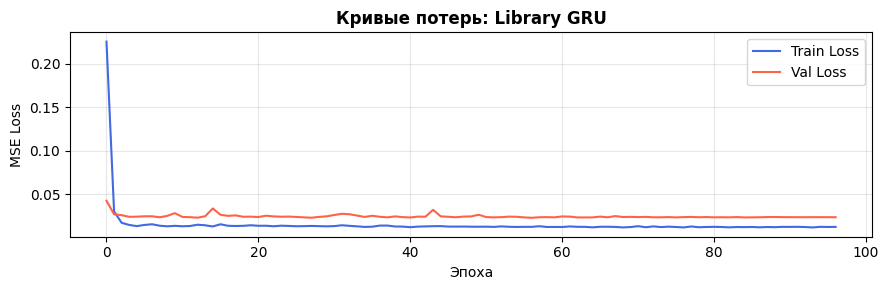

Оценка LibGRU на тесте:
  [Library GRU] MAE=859.1 | RMSE=1196.1 | R²=0.5960


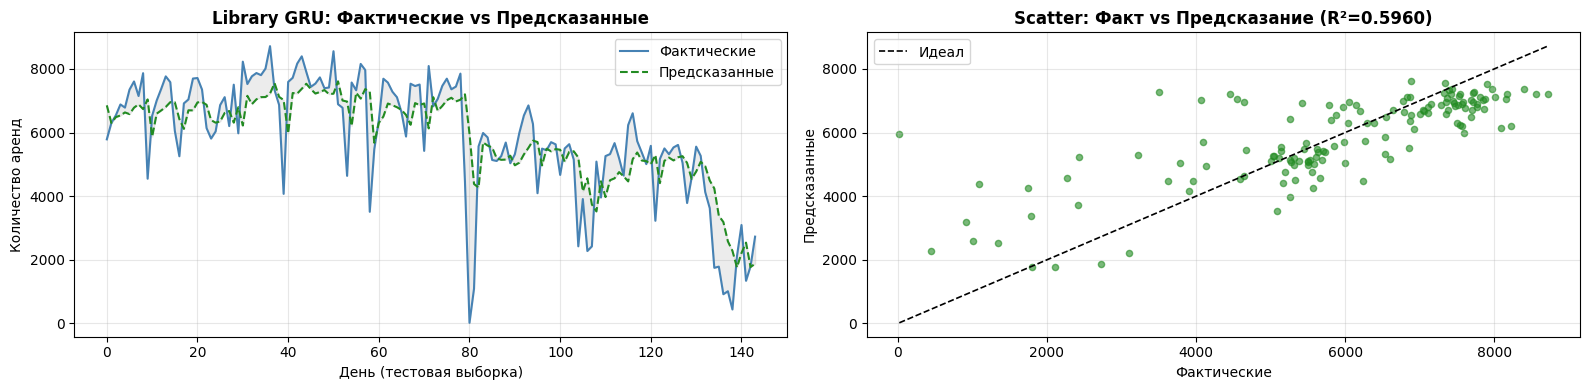

In [165]:
class LibGRU(nn.Module):
    """Библиотечная реализация GRU через torch.nn.GRU."""
    def __init__(self, input_size, hidden_size, num_layers=2, output_size=1, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.gru(x)
        out = self.dropout(out[:, -1, :])
        return self.fc(out)


print('=== Библиотечная GRU ===')
lib_gru = LibGRU(INPUT_SIZE, HIDDEN_SIZE, num_layers=1).to(device)
print(f'Параметров: {sum(p.numel() for p in lib_gru.parameters()):,}')

print('Обучение LibGRU...')
gru_lib_train_losses, gru_lib_val_losses = train_model(
    lib_gru, train_loader, X_val_t, y_val_t,
    epochs=EPOCHS, lr=1e-1, patience=40
)
plot_loss(gru_lib_train_losses, gru_lib_val_losses, 'Library GRU')

print('Оценка LibGRU на тесте:')
y_true_gru_l, y_pred_gru_l, metrics_gru_l = evaluate_model(
    lib_gru, X_test_t, y_test_t, scaler_y, 'Library GRU'
)
plot_predictions(y_true_gru_l, y_pred_gru_l, 'Library GRU', color='forestgreen')

---
## 6. LSTM (Long Short-Term Memory)

### 6.1. Ручная реализация LSTM

Формулы:
$$f_t = \sigma(W_f x_t + U_f h_{t-1} + b_f)$$
$$i_t = \sigma(W_i x_t + U_i h_{t-1} + b_i)$$
$$o_t = \sigma(W_o x_t + U_o h_{t-1} + b_o)$$
$$\tilde{c}_t = \tanh(W_c x_t + U_c h_{t-1} + b_c)$$
$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$$
$$h_t = o_t \odot \tanh(c_t)$$

=== Ручная LSTM (numpy + BPTT) ===
Параметров: 1,169
Обучение ManualLSTM...
  Эпоха   50 | Train Loss: 0.014141 | Val Loss: 0.024542
  Эпоха  100 | Train Loss: 0.015246 | Val Loss: 0.024519
  Ранняя остановка на эпохе 118


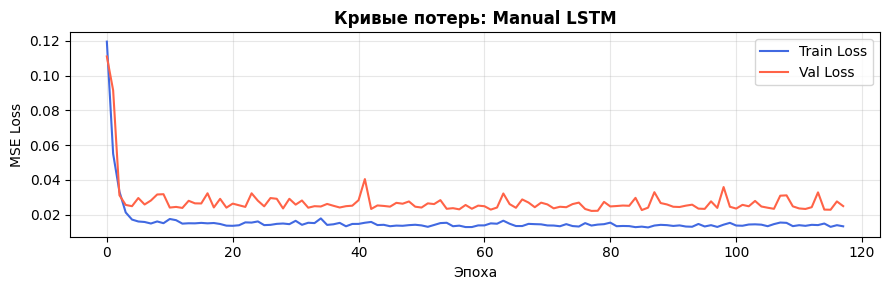

Оценка ManualLSTM на тесте:
  [Manual LSTM] MAE=844.5 | RMSE=1179.4 | R²=0.6072


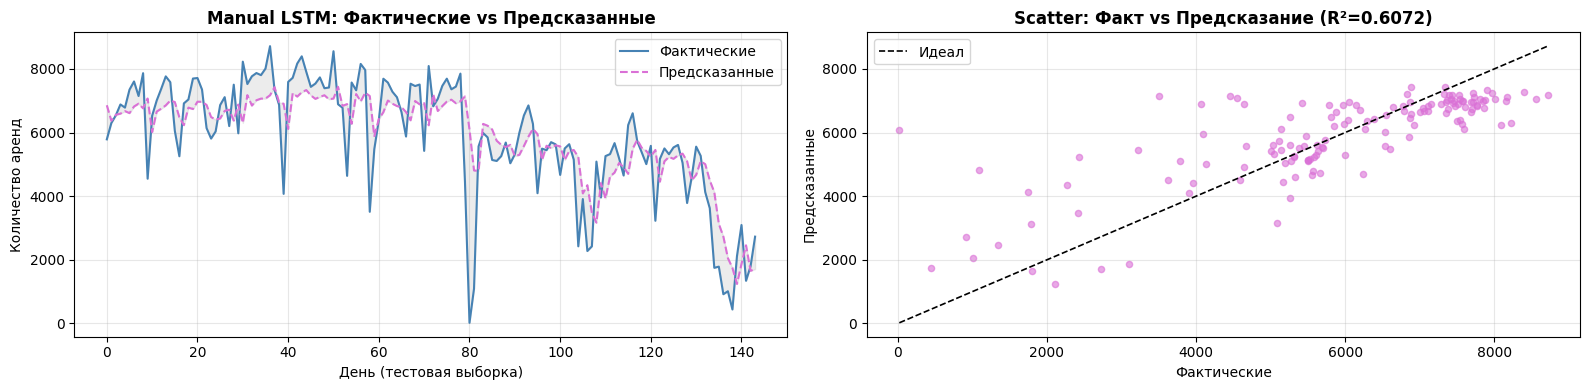

In [166]:
class ManualLSTM:
    """
    Ручная реализация LSTM на чистом numpy.
    Прямой проход, BPTT по всем четырём вентилям — без autograd PyTorch.

    f_t   = σ(W_f x_t + U_f h_{t-1} + b_f)
    i_t   = σ(W_i x_t + U_i h_{t-1} + b_i)
    o_t   = σ(W_o x_t + U_o h_{t-1} + b_o)
    c̃_t  = tanh(W_c x_t + U_c h_{t-1} + b_c)
    c_t   = f_t ⊙ c_{t-1} + i_t ⊙ c̃_t
    h_t   = o_t ⊙ tanh(c_t)
    """
    def __init__(self, input_size, hidden_size, output_size=1, dropout_rate=0.2):
        self.hidden_size  = hidden_size
        self.dropout_rate = dropout_rate
        self.training     = True
        k = 0.1

        self.params = {
            'W_f':  np.random.randn(hidden_size, input_size)  * k,
            'U_f':  np.random.randn(hidden_size, hidden_size) * k,
            'b_f':  np.ones(hidden_size),            # инициализация 1 — стандартный приём
            'W_i':  np.random.randn(hidden_size, input_size)  * k,
            'U_i':  np.random.randn(hidden_size, hidden_size) * k,
            'b_i':  np.zeros(hidden_size),
            'W_o':  np.random.randn(hidden_size, input_size)  * k,
            'U_o':  np.random.randn(hidden_size, hidden_size) * k,
            'b_o':  np.zeros(hidden_size),
            'W_c':  np.random.randn(hidden_size, input_size)  * k,
            'U_c':  np.random.randn(hidden_size, hidden_size) * k,
            'b_c':  np.zeros(hidden_size),
            'W_hy': np.random.randn(output_size, hidden_size) * k,
            'b_y':  np.zeros(output_size),
        }
        self.opt = _ManualAdam(lr=1e-1)

    # ------------------------------------------------------------------
    def forward(self, x):
        bs, seq_len, _ = x.shape
        p  = self.params
        h  = np.zeros((bs, self.hidden_size), dtype=x.dtype)
        c  = np.zeros((bs, self.hidden_size), dtype=x.dtype)

        self._cache_t = []
        for t in range(seq_len):
            x_t = x[:, t, :]

            f       = _sigmoid(x_t @ p['W_f'].T + h @ p['U_f'].T + p['b_f'])
            i_gate  = _sigmoid(x_t @ p['W_i'].T + h @ p['U_i'].T + p['b_i'])
            o       = _sigmoid(x_t @ p['W_o'].T + h @ p['U_o'].T + p['b_o'])
            c_tilde = np.tanh( x_t @ p['W_c'].T + h @ p['U_c'].T + p['b_c'])

            c_new = f * c + i_gate * c_tilde
            h_new = o * np.tanh(c_new)

            self._cache_t.append({
                'x_t': x_t, 'h_prev': h, 'c_prev': c,
                'f': f, 'i_gate': i_gate, 'o': o,
                'c_tilde': c_tilde, 'c': c_new,
            })
            h, c = h_new, c_new

        h_drop, self._drop_mask = _manual_dropout(h, self.dropout_rate, self.training)
        y = h_drop @ p['W_hy'].T + p['b_y']
        self._h_drop = h_drop
        return y

    # ------------------------------------------------------------------
    def backward(self, dy):
        """BPTT через все четыре вентиля LSTM."""
        p     = self.params
        bs    = dy.shape[0]
        grads = {k: np.zeros_like(v) for k, v in p.items()}

        grads['W_hy'] = dy.T @ self._h_drop
        grads['b_y']  = dy.sum(axis=0)

        if self._drop_mask is not None:
            dh = (dy @ p['W_hy']) * self._drop_mask
        else:
            dh = dy @ p['W_hy']

        dc = np.zeros_like(dh)    # накопленный градиент по c_{t+1}

        for t in reversed(range(len(self._cache_t))):
            ct      = self._cache_t[t]
            x_t     = ct['x_t']; h_prev = ct['h_prev']; c_prev = ct['c_prev']
            f       = ct['f'];   i_gate  = ct['i_gate']; o      = ct['o']
            c_tilde = ct['c_tilde']; c  = ct['c']

            tanh_c = np.tanh(c)

            # h_t = o ⊙ tanh(c_t) → градиенты по o и c
            d_o         = dh * tanh_c                        # ∂L/∂o
            dc_from_h   = dh * o * (1.0 - tanh_c ** 2)      # через tanh(c)
            dc          = dc + dc_from_h                     # + carry из t+1

            # c_t = f⊙c_{t-1} + i⊙c̃ → градиенты по f, i, c̃
            d_f         = dc * c_prev
            d_i         = dc * c_tilde
            d_c_tilde   = dc * i_gate

            # sigmoid backward
            d_pre_f     = d_f       * f      * (1.0 - f)
            d_pre_i     = d_i       * i_gate * (1.0 - i_gate)
            d_pre_o     = d_o       * o      * (1.0 - o)
            # tanh backward
            d_pre_c     = d_c_tilde * (1.0 - c_tilde ** 2)

            grads['W_f'] += d_pre_f.T @ x_t
            grads['U_f'] += d_pre_f.T @ h_prev
            grads['b_f'] += d_pre_f.sum(axis=0)

            grads['W_i'] += d_pre_i.T @ x_t
            grads['U_i'] += d_pre_i.T @ h_prev
            grads['b_i'] += d_pre_i.sum(axis=0)

            grads['W_o'] += d_pre_o.T @ x_t
            grads['U_o'] += d_pre_o.T @ h_prev
            grads['b_o'] += d_pre_o.sum(axis=0)

            grads['W_c'] += d_pre_c.T @ x_t
            grads['U_c'] += d_pre_c.T @ h_prev
            grads['b_c'] += d_pre_c.sum(axis=0)

            # Передаём градиент к h_{t-1} и c_{t-1}
            dh = (d_pre_f @ p['U_f'] + d_pre_i @ p['U_i']
                + d_pre_o @ p['U_o'] + d_pre_c @ p['U_c'])
            dc = dc * f                                      # ∂c_t/∂c_{t-1} = f

        total_norm = np.sqrt(sum(np.sum(g**2) for g in grads.values()))
        if total_norm > 1.0:
            for k in grads:
                grads[k] = grads[k] / total_norm

        return grads

    # ------------------------------------------------------------------
    def step(self, x, y_true):
        y_pred = self.forward(x)
        loss   = float(np.mean((y_pred - y_true) ** 2))
        dy     = 2.0 * (y_pred - y_true) / x.shape[0]
        grads  = self.backward(dy)
        self.opt.step(self.params, grads)
        return loss


print('=== Ручная LSTM (numpy + BPTT) ===')
manual_lstm = ManualLSTM(INPUT_SIZE, HIDDEN_SIZE)
total = sum(v.size for v in manual_lstm.params.values())
print(f'Параметров: {total:,}')

print('Обучение ManualLSTM...')
lstm_manual_train_losses, lstm_manual_val_losses = train_manual_model(
    manual_lstm, X_train_np, y_train_np, X_val_np, y_val_np,
    epochs=EPOCHS, batch_size=32, patience=40
)
plot_loss(lstm_manual_train_losses, lstm_manual_val_losses, 'Manual LSTM')

print('Оценка ManualLSTM на тесте:')
y_true_lstm_m, y_pred_lstm_m, metrics_lstm_m = evaluate_manual_model(
    manual_lstm, X_test_np, y_test_np_arr, _y_mn, _y_mx, 'Manual LSTM'
)
plot_predictions(y_true_lstm_m, y_pred_lstm_m, 'Manual LSTM', color='orchid')


### 6.2. Библиотечная реализация LSTM (torch.nn.LSTM)

=== Библиотечная LSTM ===
Параметров: 1,233
Обучение LibLSTM...
  Эпоха   50 | Train Loss: 0.012626 | Val Loss: 0.024871
  Ранняя остановка на эпохе 78


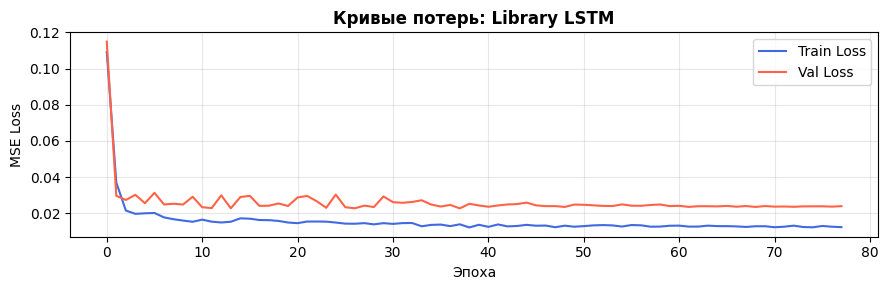

Оценка LibLSTM на тесте:
  [Library LSTM] MAE=868.4 | RMSE=1196.4 | R²=0.5958


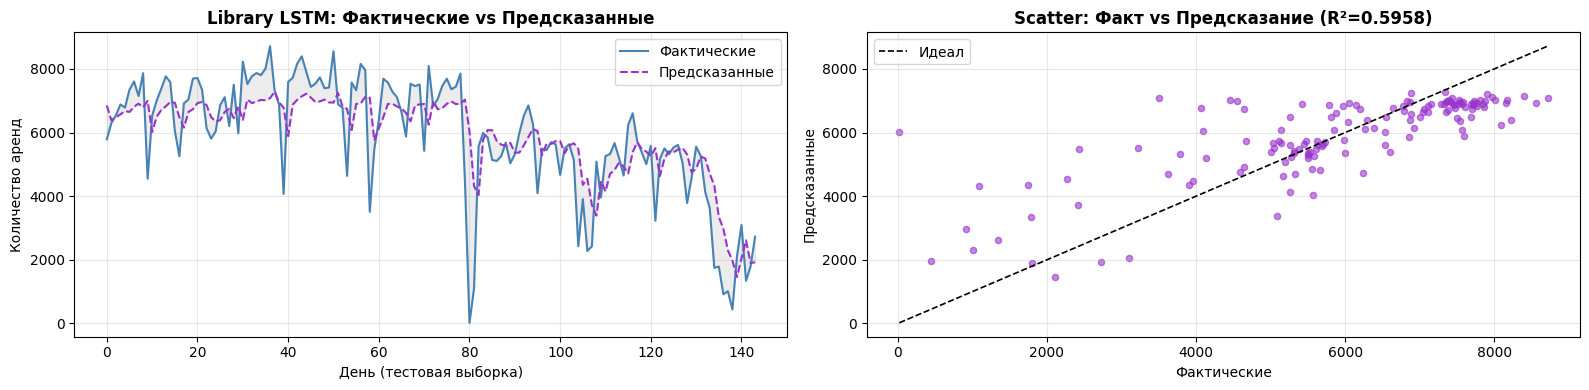

In [167]:
class LibLSTM(nn.Module):
    """Библиотечная реализация LSTM через torch.nn.LSTM."""
    def __init__(self, input_size, hidden_size, num_layers=2, output_size=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout(out[:, -1, :])
        return self.fc(out)


print('=== Библиотечная LSTM ===')
lib_lstm = LibLSTM(INPUT_SIZE, hidden_size=16, num_layers=1, dropout=0.3).to(device)
print(f'Параметров: {sum(p.numel() for p in lib_lstm.parameters()):,}')

print('Обучение LibLSTM...')
lstm_lib_train_losses, lstm_lib_val_losses = train_model(
    lib_lstm, train_loader, X_val_t, y_val_t,
    epochs=200, lr=1e-1, patience=40
)
plot_loss(lstm_lib_train_losses, lstm_lib_val_losses, 'Library LSTM')

print('Оценка LibLSTM на тесте:')
y_true_lstm_l, y_pred_lstm_l, metrics_lstm_l = evaluate_model(
    lib_lstm, X_test_t, y_test_t, scaler_y, 'Library LSTM'
)
plot_predictions(y_true_lstm_l, y_pred_lstm_l, 'Library LSTM', color='darkorchid')

---
## 7. Сравнительный анализ всех моделей

In [168]:
# ==============================
# Таблица метрик
# ==============================

results = {
    'Manual RNN':   metrics_rnn_m,
    'Library RNN':  metrics_rnn_l,
    'Manual GRU':   metrics_gru_m,
    'Library GRU':  metrics_gru_l,
    'Manual LSTM':  metrics_lstm_m,
    'Library LSTM': metrics_lstm_l,
}

df_results = pd.DataFrame(results).T
df_results = df_results[['MAE', 'RMSE', 'R2']]
df_results = df_results.round(2)

print('\n========== СВОДНАЯ ТАБЛИЦА МЕТРИК ==========')
print(df_results.to_string())
print('\n(MAE, RMSE — меньше лучше; R² — больше лучше)')


========== СВОДНАЯ ТАБЛИЦА МЕТРИК ==========
                 MAE     RMSE    R2
Manual RNN    863.63  1209.19  0.59
Library RNN   882.81  1235.94  0.57
Manual GRU    870.91  1181.93  0.61
Library GRU   859.09  1196.06  0.60
Manual LSTM   844.49  1179.40  0.61
Library LSTM  868.39  1196.38  0.60

(MAE, RMSE — меньше лучше; R² — больше лучше)


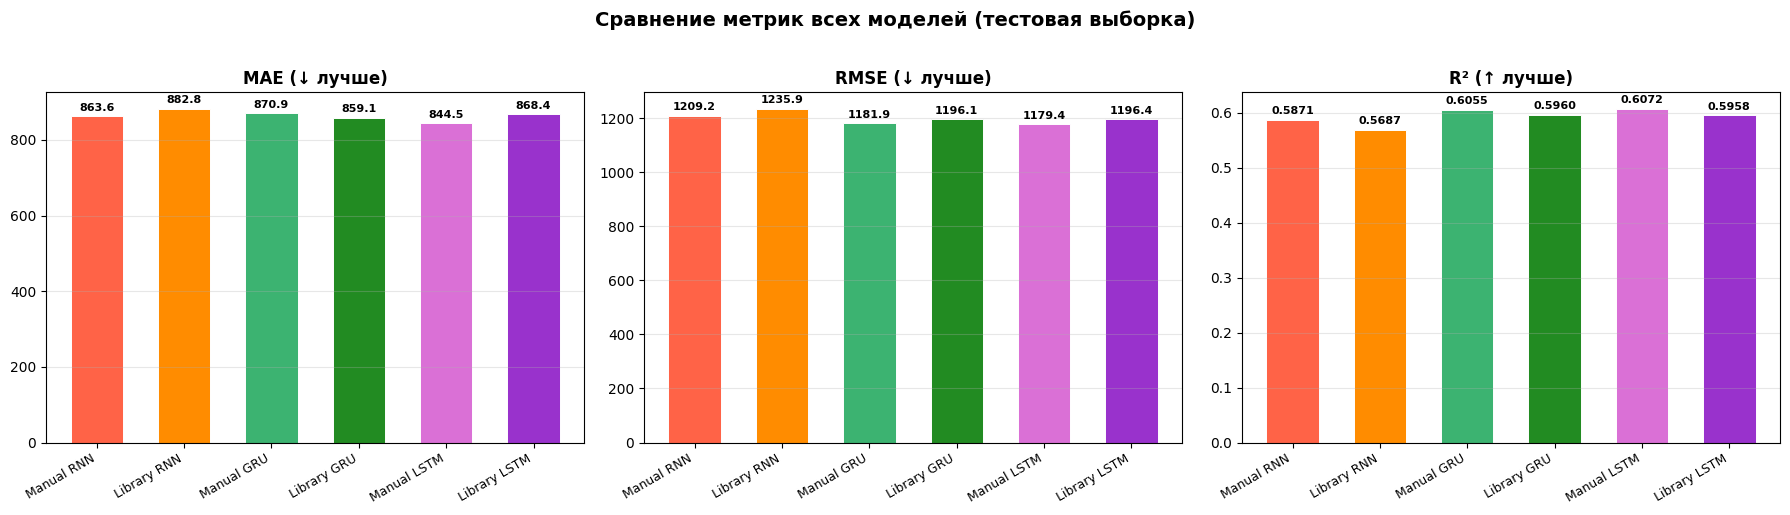

In [169]:
# ==============================
# Гистограмма метрик
# ==============================

models   = list(results.keys())
colors   = ['tomato', 'darkorange', 'mediumseagreen', 'forestgreen', 'orchid', 'darkorchid']
mae_vals  = [results[m]['MAE']  for m in models]
rmse_vals = [results[m]['RMSE'] for m in models]
r2_vals   = [results[m]['R2']   for m in models]

x = np.arange(len(models))
width = 0.6

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, vals, title, better in zip(
    axes,
    [mae_vals, rmse_vals, r2_vals],
    ['MAE (↓ лучше)', 'RMSE (↓ лучше)', 'R² (↑ лучше)'],
    [True, True, False]
):
    bars = ax.bar(x, vals, color=colors, width=width, edgecolor='white', linewidth=0.7)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=30, ha='right', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(vals)*0.01,
                f'{val:.1f}' if val > 10 else f'{val:.4f}',
                ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('Сравнение метрик всех моделей (тестовая выборка)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

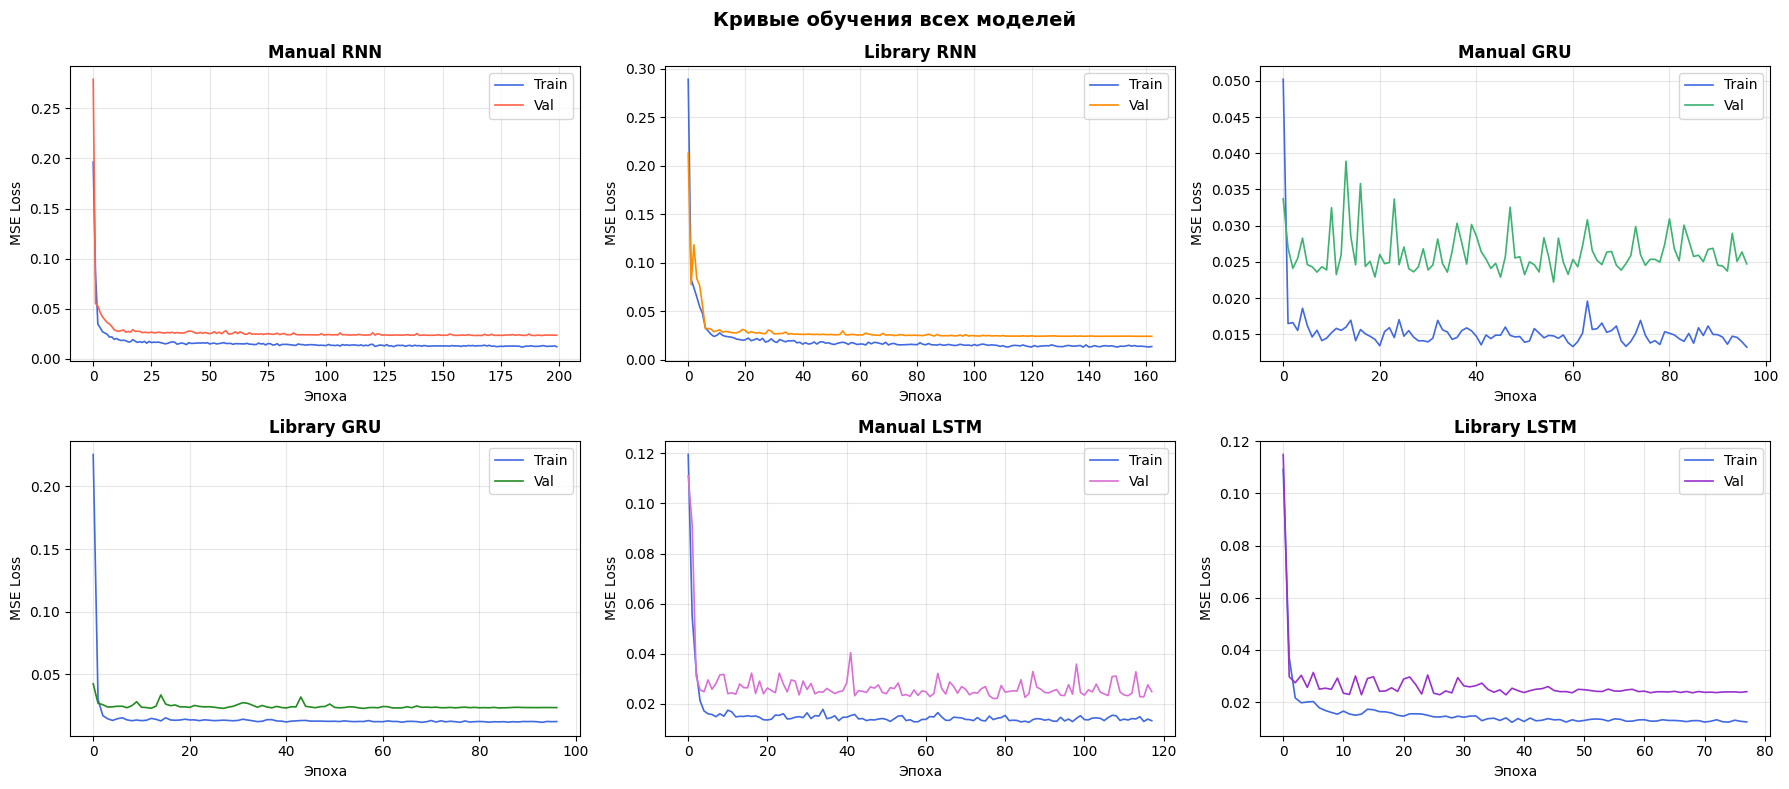

In [170]:
# ==============================
# Кривые потерь всех моделей
# ==============================

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

loss_data = [
    (rnn_manual_train_losses,  rnn_manual_val_losses,  'Manual RNN',   'tomato'),
    (rnn_lib_train_losses,     rnn_lib_val_losses,     'Library RNN',  'darkorange'),
    (gru_manual_train_losses,  gru_manual_val_losses,  'Manual GRU',   'mediumseagreen'),
    (gru_lib_train_losses,     gru_lib_val_losses,     'Library GRU',  'forestgreen'),
    (lstm_manual_train_losses, lstm_manual_val_losses, 'Manual LSTM',  'orchid'),
    (lstm_lib_train_losses,    lstm_lib_val_losses,    'Library LSTM', 'darkorchid'),
]

for ax, (tr_l, val_l, name, col) in zip(axes, loss_data):
    ax.plot(tr_l,  label='Train', color='royalblue', linewidth=1.2)
    ax.plot(val_l, label='Val',   color=col,         linewidth=1.2)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Эпоха')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Кривые обучения всех моделей', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

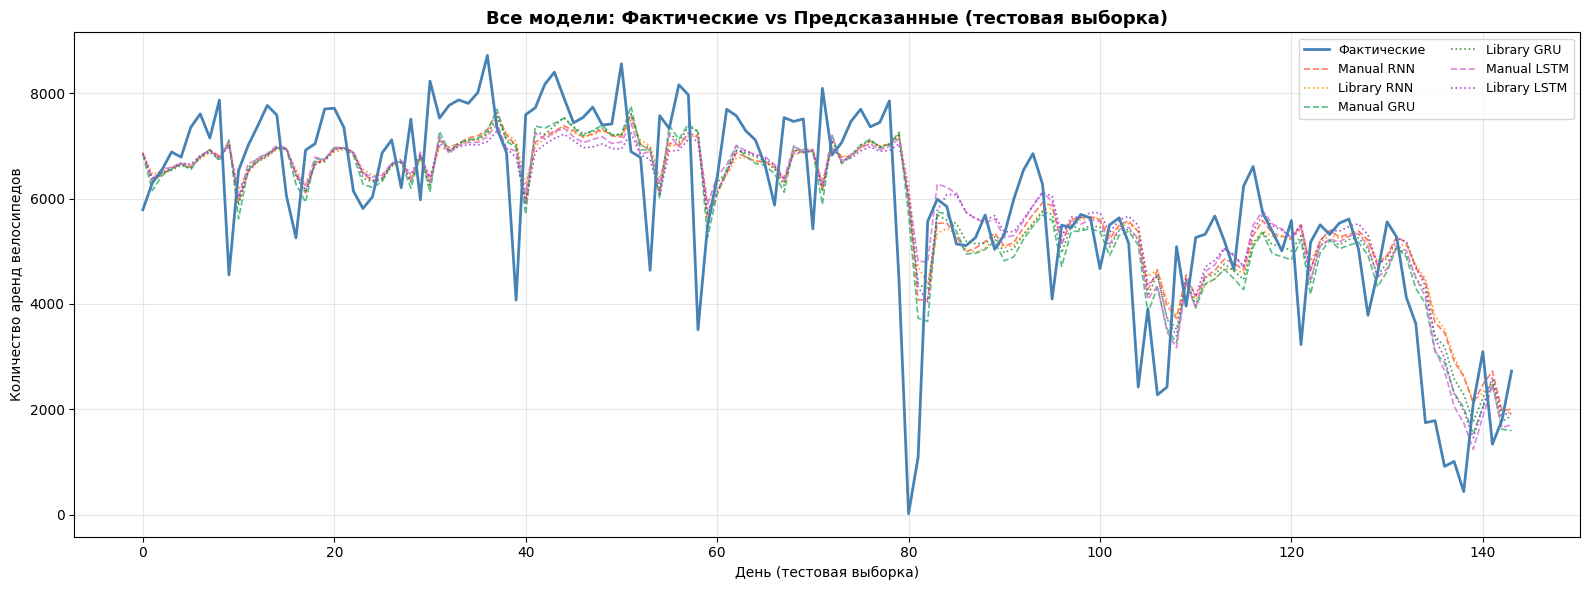

In [171]:
# ==============================
# Сравнение предсказаний всех моделей на одном графике
# ==============================

preds_data = [
    (y_pred_rnn_m,  'Manual RNN',   'tomato',       '--'),
    (y_pred_rnn_l,  'Library RNN',  'darkorange',   ':'),
    (y_pred_gru_m,  'Manual GRU',   'mediumseagreen','--'),
    (y_pred_gru_l,  'Library GRU',  'forestgreen',  ':'),
    (y_pred_lstm_m, 'Manual LSTM',  'orchid',       '--'),
    (y_pred_lstm_l, 'Library LSTM', 'darkorchid',   ':'),
]

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(y_true_rnn_m, label='Фактические', color='steelblue', linewidth=2.0, zorder=10)

for y_pred, name, col, ls in preds_data:
    ax.plot(y_pred, label=name, color=col, linewidth=1.2, linestyle=ls, alpha=0.85)

ax.set_title('Все модели: Фактические vs Предсказанные (тестовая выборка)', fontsize=13, fontweight='bold')
ax.set_xlabel('День (тестовая выборка)')
ax.set_ylabel('Количество аренд велосипедов')
ax.legend(ncol=2, fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

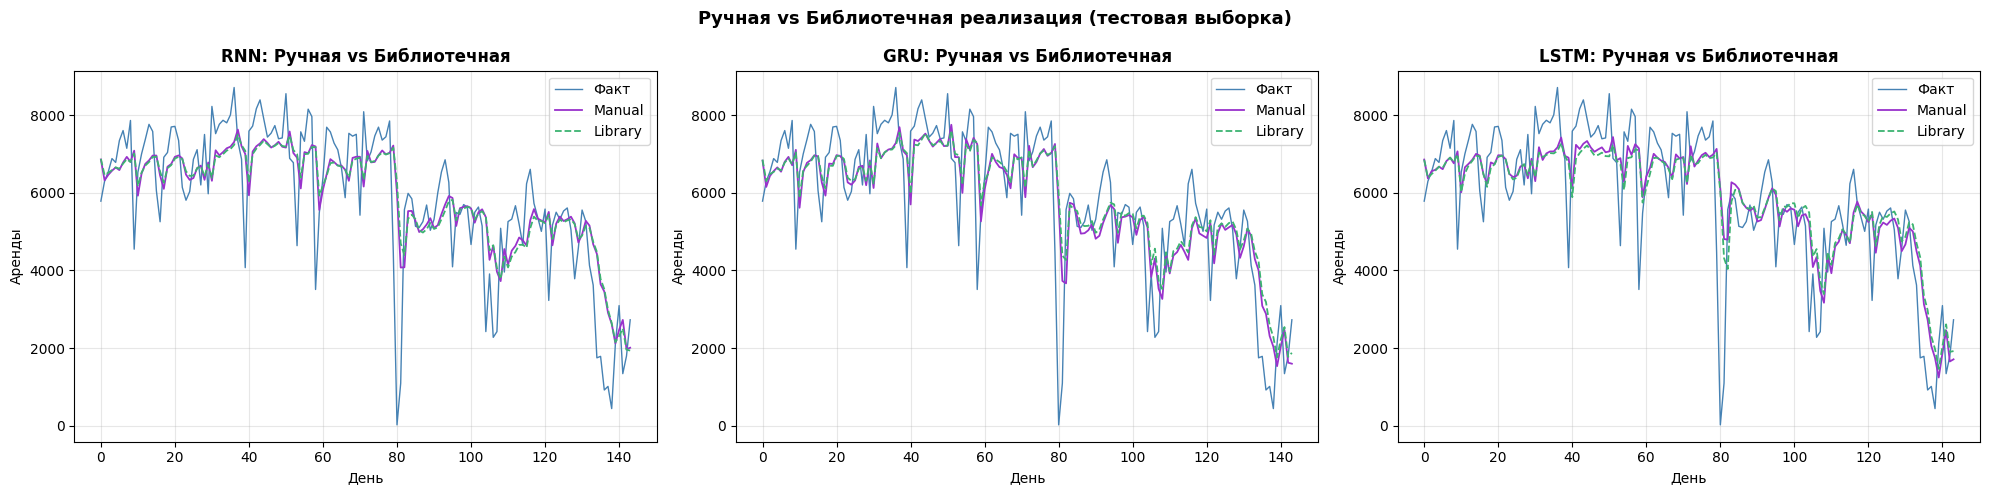

In [172]:
# ==============================
# Ручная vs Библиотечная для каждой архитектуры
# ==============================

arch_pairs = [
    ('RNN',  y_true_rnn_m,  y_pred_rnn_m,  y_pred_rnn_l,  'darkorchid', 'mediumseagreen'),
    ('GRU',  y_true_gru_m,  y_pred_gru_m,  y_pred_gru_l,  'darkorchid', 'mediumseagreen'),
    ('LSTM', y_true_lstm_m, y_pred_lstm_m, y_pred_lstm_l, 'darkorchid', 'mediumseagreen'),
]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, (name, y_true, y_m, y_l, cm, cl) in zip(axes, arch_pairs):
    ax.plot(y_true, label='Факт',       color='steelblue', linewidth=1.0)
    ax.plot(y_m,    label=f'Manual',    color=cm,          linewidth=1.3)
    ax.plot(y_l,    label=f'Library',   color=cl,          linewidth=1.3, linestyle="--")
    ax.set_title(f'{name}: Ручная vs Библиотечная', fontweight='bold')
    ax.set_xlabel('День')
    ax.set_ylabel('Аренды')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Ручная vs Библиотечная реализация (тестовая выборка)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [173]:
# ==============================
# Финальная сводка
# ==============================

print('\n' + '='*55)
print('           ИТОГОВАЯ СВОДКА РЕЗУЛЬТАТОВ')
print('='*55)
print(f'{"Модель":<18} {"MAE":>8} {"RMSE":>8} {"R²":>8}')
print('-'*55)

best_r2  = max(results[m]['R2']  for m in results)
best_mae = min(results[m]['MAE'] for m in results)

for name, m in results.items():
    flag = '  ← лучший R²' if abs(m['R2'] - best_r2) < 1e-4 else ''
    flag = '  ← лучший MAE' if abs(m['MAE'] - best_mae) < 1e-4 else flag
    print(f'{name:<18} {m["MAE"]:>8.1f} {m["RMSE"]:>8.1f} {m["R2"]:>8.4f}{flag}')

print('='*55)
print('\nВыводы:')
print('• Ручные реализации воспроизводят математику вентилей')
print('  и дают сопоставимые результаты с библиотечными.')
print('• GRU и LSTM обычно превосходят базовую RNN благодаря')
print('  механизму вентилей и долгосрочной памяти.')
print('• Библиотечные реализации быстрее обучаются за счёт')
print('  оптимизированных CUDA-ядер.')


           ИТОГОВАЯ СВОДКА РЕЗУЛЬТАТОВ
Модель                  MAE     RMSE       R²
-------------------------------------------------------
Manual RNN            863.6   1209.2   0.5871
Library RNN           882.8   1235.9   0.5687
Manual GRU            870.9   1181.9   0.6055
Library GRU           859.1   1196.1   0.5960
Manual LSTM           844.5   1179.4   0.6072  ← лучший MAE
Library LSTM          868.4   1196.4   0.5958

Выводы:
• Ручные реализации воспроизводят математику вентилей
  и дают сопоставимые результаты с библиотечными.
• GRU и LSTM обычно превосходят базовую RNN благодаря
  механизму вентилей и долгосрочной памяти.
• Библиотечные реализации быстрее обучаются за счёт
  оптимизированных CUDA-ядер.
